In [1]:
%load_ext autoreload
%autoreload 2

import os, pickle, warnings
import pandas as pd
import geopandas as gpd
import numpy as np

from patsy import dmatrices
from statsmodels.api import OLS

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.nonparametric.kernel_regression import KernelReg

from itertools import chain, combinations

import pyarrow.parquet as pq

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LightSource
from matplotlib.ticker import FormatStrFormatter

from sklearn.preprocessing import QuantileTransformer
warnings.filterwarnings(action='ignore',
                        category=UserWarning)

from joblib import Parallel, delayed

import calendar


from importlib import reload

import PyCrossTRF as ctrf
reload(ctrf) 

Cross TRF package load
Cross TRF package load


<module 'PyCrossTRF' from 'c:\\Users\\SeanJ\\Repositories\\Research_Mortality_cTRF\\PyCrossTRF\\__init__.py'>

In [2]:
df = pd.read_pickle(r'50_estm_data_gen_df.pkl')
df
pq_order = {'p':5, 'q':2}
dep_var  = 'ln_daily_death100k'
temp_r   = 'p_AirTemp'
covariates = {
        'AirTemp':{'scale':'minmax'},
        'RelHumidity':{'scale':'standard'},
        # 'SeaLevelPressure':{'scale':'standard'},
        'WindSpeedRate':{'scale':'standard'},
        'PrecipDepth1hr':{'scale':'standard'},
        'SkyConditionCode':{'scale':'standard'},
        'p_AirTemp':{'scale':'minmax'},
        'p_RelHumidity':{'scale':'standard'},
        # 'p_SeaLevelPressure':{'scale':'standard'},
        'p_WindSpeedRate':{'scale':'standard'},
        'p_PrecipDepth1hr':{'scale':'standard'},
        'p_SkyConditionCode':{'scale':'standard'},
        'date_lin':{'scale':'time'}, 
        'ln_inc_adj15':{'scale':'standard'},
        'age_mean':{'scale':'standard'},
        'ln_age_mean':{'scale':'standard'},
        }

# lst_meta = ['AirTemp','RelHumidity','WindSpeedRate','PrecipDepth1hr','SkyConditionCode']
df_pct = df [['fips','date',dep_var,temp_r]+list(covariates.keys())].copy()
df_stat = df_pct.dropna().groupby('fips').count().reset_index()
 
df_pct_full = df_pct.loc[df_pct['fips'].isin(df_stat.loc[df_stat['date']==252]['fips'])]
df_pct_full = df_pct_full.reset_index(drop=True)
df_pct_full


pq_order_updated = pq_order

covariates = {
        'p_AirTemp':{'scale':'minmax'},
        'date_lin':{'scale':'time'}, 
        'ln_age_mean':{'scale':'standard'},
        'ln_inc_adj15':{'scale':'standard'},
        'p_WindSpeedRate':{'scale':'standard'},
        'p_SkyConditionCode':{'scale':'standard'},
        'p_RelHumidity':{'scale':'standard'},
        'p_PrecipDepth1hr':{'scale':'standard'},
        }


df_to_reg = df.dropna(subset=list(covariates.keys())).reset_index(drop=True)

fips_252_length = df_to_reg[['fips','date']].copy().groupby('fips').agg('count').reset_index()
fips_252_length = fips_252_length.loc[fips_252_length['date'] ==252]['fips'].reset_index(drop=True)
fips_252_length

df_to_reg = df_to_reg.loc[df_to_reg['fips'].isin(fips_252_length)].dropna().reset_index()
df_to_reg = df_to_reg.sort_values(by=['fips','date'], ascending=[True, False]).reset_index(drop=True)





pq_order = {'p':5, 'q':2}
dep_var  = 'ln_daily_death100k'
temp_r   = 'p_AirTemp'

model_trf_ln = ctrf.CTRF( df=df_to_reg, 
                    dep= dep_var ,
                    temp_r= temp_r, 
                    pq_order=pq_order, 
                    cov_scale={'p_AirTemp':{'scale':'minmax'}})
model_trf_ln.estimate_ctrf(verbose=False)
# print(model_trf_ln.reg_res_ctrf.summary())


model_trf_ln.reg_res_trf.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     ln_daily_death100k   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     191.3
Date:                Sat, 04 Jan 2025   Prob (F-statistic):               0.00
Time:                        18:06:03   Log-Likelihood:                 2734.8
No. Observations:               21360   AIC:                            -5450.
Df Residuals:                   21350   BIC:                            -5370.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.4741      0.669      0.708      0.479      -0.838       1.786
p_AirTemp_10      8.3013     23.988      0.346      0.729     -38.716      55.319
p_AirTemp_20     24.2114     37.781      0.641      0.522     -49.843      98.265
p_AirTemp_30   -154.6603    340.835     -0.454      0.650    -822.722     513.401
p_AirTemp_40    193.7463    474.568      0.408      0.683    -736.443    1123.936
p_AirTemp_50    -71.7323    187.434     -0.383      0.702    -439.116     295.652
p_AirTemp_01c     0.4247      0.681      0.624      0.533      -0.910       1.759
p_AirTemp_01s    -1.4260      3.936     -0.362      0.717      -9.141       6.289
p_AirTemp_02c     0.0229      0.027      0.847      0.397      -0.030       0.076
p_AirTemp_02s    -0.0052      0.070     -0.073      0.942      -0.143       0.133
==============================================================================
Omnibus:                      736.673   Durbin-Watson:                   0.260
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              793.683
Skew:                          -0.460   Prob(JB):                    4.51e-173
Kurtosis:                       2.783   Cond. No.                     5.61e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.61e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
_sbs = ctrf.sieve_bs.SieveBootstrap(CTRF=model_trf_ln, df_reg=df_to_reg)
_sbs.generate_residuals()
_sbs.df_eta_hat


Vars to generate eta_hat ['Intercept', 'p_AirTemp_10', 'p_AirTemp_20', 'p_AirTemp_30', 'p_AirTemp_40', 'p_AirTemp_50', 'p_AirTemp_01c', 'p_AirTemp_01s', 'p_AirTemp_02c', 'p_AirTemp_02s']


,date,fips,eta_hat,T
0,2002-12-01,01089,0.917785,239
1,2002-11-01,01089,0.879105,238
2,2002-10-01,01089,0.798932,237
3,2002-09-01,01089,0.749842,236
4,2002-08-01,01089,0.758211,235
...,...,...,...,...
21355,1983-05-01,55025,0.794769,4
21356,1983-04-01,55025,0.821909,3
21357,1983-03-01,55025,0.868119,2
21358,1983-02-01,55025,0.908942,1


In [25]:
_sbs.generate_e_hat()

In [26]:
_sbs.bootstrapping_e_star()

In [27]:
_sbs.generate_eta_star()

KeyboardInterrupt: 

In [ ]:
_sbs.generate_y_star()

In [3]:
# for CTRF.
pq_order = {'p':5, 'q':2}
dep_var  = 'ln_daily_death100k'
temp_r   = 'p_AirTemp'

model_ctrf_ln = ctrf.CTRF( df=df_to_reg, 
                    dep= dep_var ,
                    temp_r= temp_r, 
                    pq_order= {'p':5, 'q':2}, 
                    cov_scale=covariates)
model_ctrf_ln.estimate_ctrf(verbose=False)
# 
_sbs_ctrf = ctrf.sieve_bs.SieveBootstrap(CTRF=model_ctrf_ln, df_reg=df_to_reg)
_sbs_ctrf.generate_residuals()
_sbs_ctrf.df_eta_hat


Vars to generate eta_hat ['Intercept', 'p_AirTemp_10', 'p_AirTemp_20', 'p_AirTemp_30', 'p_AirTemp_40', 'p_AirTemp_50', 'p_AirTemp_01c', 'p_AirTemp_01s', 'p_AirTemp_02c', 'p_AirTemp_02s']


,date,fips,eta_hat,T
0,2002-12-01,01089,0.907170,239
1,2002-11-01,01089,0.823706,238
2,2002-10-01,01089,0.784056,237
3,2002-09-01,01089,0.757438,236
4,2002-08-01,01089,0.761636,235
...,...,...,...,...
21355,1983-05-01,55025,0.783455,4
21356,1983-04-01,55025,0.765141,3
21357,1983-03-01,55025,0.808314,2
21358,1983-02-01,55025,0.874487,1


In [4]:
_sbs_ctrf.generate_e_hat()

In [5]:
# _sbs_ctrf.bootstrapping_e_star(parallel=False)
_sbs_ctrf.bootstrapping_e_star()

In [6]:
_sbs_ctrf.generate_eta_star()

In [7]:
_sbs_ctrf.generate_y_star()

In [8]:
_sbs_ctrf.B_df_y_star

,index,y_star_0,y_star_1,y_star_2,y_star_3,y_star_4,y_star_5,y_star_6,y_star_7,y_star_8,...,y_star_990,y_star_991,y_star_992,y_star_993,y_star_994,y_star_995,y_star_996,y_star_997,y_star_998,y_star_999
0,0,0.855992,1.818647,1.768281,1.743651,1.817223,1.888727,1.789868,1.888859,1.777318,...,1.873696,1.840491,1.721180,1.778268,1.788621,1.727997,1.775228,1.816347,1.891901,1.829368
1,1,0.772194,1.788904,1.757223,1.707544,1.658321,1.734664,1.735799,1.860714,1.708369,...,1.779054,1.726911,1.583715,1.698407,1.683702,1.645915,1.701555,1.727162,1.750628,1.692339
2,2,0.791772,1.711318,1.727137,1.652461,1.578087,1.715578,1.693438,1.766061,1.658001,...,1.693905,1.635225,1.576704,1.661681,1.619202,1.605573,1.592693,1.641520,1.619993,1.666150
3,3,0.664441,1.639105,1.684256,1.577706,1.612755,1.552285,1.628520,1.656761,1.529784,...,1.561323,1.673398,1.503145,1.615400,1.576536,1.741307,1.525637,1.567918,1.572120,1.607212
4,4,0.625645,1.723579,1.595743,1.658873,1.651771,1.480846,1.636994,1.603767,1.612490,...,1.551578,1.519641,1.466803,1.608227,1.578174,1.624643,1.490461,1.569370,1.677395,1.674301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19219,21331,0.523389,1.270726,1.267998,1.287121,1.320828,1.262216,1.274579,1.226757,1.309539,...,1.275896,1.263899,1.326209,1.183070,1.256791,1.266273,1.343642,1.348652,1.221073,1.268940
19220,21332,0.411348,1.290204,1.345017,1.302969,1.602647,1.330510,1.361292,1.295428,1.382349,...,1.322016,1.304215,1.389828,1.250977,1.343633,1.342446,1.753256,1.351287,1.343377,1.346747
19221,21333,0.730677,1.425250,1.426530,1.412173,1.409561,1.441183,1.410622,1.430245,1.648347,...,1.415865,1.402517,1.827235,1.414249,1.457267,1.406875,1.436582,1.412357,1.371894,1.345293
19222,21334,0.573287,1.570200,1.559405,1.546991,1.552502,1.562024,1.529950,1.558843,1.535659,...,1.545679,1.477682,1.550024,1.542474,1.541940,1.546481,1.531367,1.537975,1.479113,1.552143


In [15]:
_sbs_ctrf.B_eta_star_y_star['1']

,date,fips,T,L1,L2,L3,L4,L5,L6,L7,...,L20,L21,L22,L23,L24,e_star,eta_star,eta_hat,fitted_y,y_star
0,2002-12-01,01089,239,0.844951,0.838786,0.817985,0.896556,0.902598,0.909798,0.887090,...,0.844423,0.840340,0.822706,0.833882,0.843566,0.003069,0.823575,0.820505,0.995073,1.818647
1,2002-11-01,01089,238,0.838786,0.817985,0.896556,0.902598,0.909798,0.887090,0.839499,...,0.840340,0.822706,0.833882,0.843566,0.807094,0.018917,0.844951,0.826034,0.943953,1.788904
2,2002-10-01,01089,237,0.817985,0.896556,0.902598,0.909798,0.887090,0.839499,0.779890,...,0.822706,0.833882,0.843566,0.807094,0.886845,-0.003387,0.838786,0.842173,0.872532,1.711318
3,2002-09-01,01089,236,0.896556,0.902598,0.909798,0.887090,0.839499,0.779890,0.839737,...,0.833882,0.843566,0.807094,0.886845,0.845732,-0.047216,0.817985,0.865201,0.821120,1.639105
4,2002-08-01,01089,235,0.902598,0.909798,0.887090,0.839499,0.779890,0.839737,0.805828,...,0.843566,0.807094,0.886845,0.845732,0.855582,0.036446,0.896556,0.860110,0.827023,1.723579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21331,1985-05-01,55025,28,0.743957,0.812863,0.905524,1.016328,0.876922,0.796315,0.783834,...,0.763784,0.769004,0.793393,0.757779,0.783455,0.003911,0.773175,0.769264,0.497550,1.270726
21332,1985-04-01,55025,27,0.812863,0.905524,1.016328,0.876922,0.796315,0.783834,0.763918,...,0.769004,0.793393,0.757779,0.783455,0.765141,-0.051685,0.743957,0.795642,0.546247,1.290204
21333,1985-03-01,55025,26,0.905524,1.016328,0.876922,0.796315,0.783834,0.763918,0.769065,...,0.793393,0.757779,0.783455,0.765141,0.808314,0.004199,0.812863,0.808664,0.612387,1.425250
21334,1985-02-01,55025,25,1.016328,0.876922,0.796315,0.783834,0.763918,0.769065,0.764474,...,0.757779,0.783455,0.765141,0.808314,0.874487,0.016880,0.905524,0.888644,0.664675,1.570200


In [18]:
_sbs_ctrf.reg_res_rho_hat.params

L1     0.168040
L2     0.004432
L3    -0.000682
L4     0.004564
L5     0.010036
L6    -0.012034
L7     0.000570
L8    -0.000282
L9    -0.030196
L10    0.049440
L11    0.097747
L12    0.240254
L13    0.166263
L14   -0.069941
L15   -0.009366
L16    0.013171
L17    0.007920
L18   -0.006249
L19    0.027278
L20    0.002438
L21   -0.008944
L22   -0.023325
L23    0.164617
L24    0.203253
dtype: float64

In [19]:
tt = _sbs_ctrf.B_eta_star_y_star['1'].copy()
tt.loc[tt['T'] == 25].filter(like='L').dot(_sbs_ctrf.reg_res_rho_hat.params)

214      0.901001
454      0.937285
694      0.890582
934      0.856911
1174     0.860870
           ...   
20374    0.804838
20614    0.802681
20854    0.860378
21094    0.898562
21334    0.888644
Length: 89, dtype: float64

In [21]:
tt['e_star']

0        0.003069
1        0.018917
2       -0.003387
3       -0.047216
4        0.036446
           ...   
21331    0.003911
21332   -0.051685
21333    0.004199
21334    0.016880
21335    0.012716
Name: e_star, Length: 19224, dtype: float64

In [22]:
tt

,date,fips,T,L1,L2,L3,L4,L5,L6,L7,...,L20,L21,L22,L23,L24,e_star,eta_star,eta_hat,fitted_y,y_star
0,2002-12-01,01089,239,0.844951,0.838786,0.817985,0.896556,0.902598,0.909798,0.887090,...,0.844423,0.840340,0.822706,0.833882,0.843566,0.003069,0.823575,0.820505,0.995073,1.818647
1,2002-11-01,01089,238,0.838786,0.817985,0.896556,0.902598,0.909798,0.887090,0.839499,...,0.840340,0.822706,0.833882,0.843566,0.807094,0.018917,0.844951,0.826034,0.943953,1.788904
2,2002-10-01,01089,237,0.817985,0.896556,0.902598,0.909798,0.887090,0.839499,0.779890,...,0.822706,0.833882,0.843566,0.807094,0.886845,-0.003387,0.838786,0.842173,0.872532,1.711318
3,2002-09-01,01089,236,0.896556,0.902598,0.909798,0.887090,0.839499,0.779890,0.839737,...,0.833882,0.843566,0.807094,0.886845,0.845732,-0.047216,0.817985,0.865201,0.821120,1.639105
4,2002-08-01,01089,235,0.902598,0.909798,0.887090,0.839499,0.779890,0.839737,0.805828,...,0.843566,0.807094,0.886845,0.845732,0.855582,0.036446,0.896556,0.860110,0.827023,1.723579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21331,1985-05-01,55025,28,0.743957,0.812863,0.905524,1.016328,0.876922,0.796315,0.783834,...,0.763784,0.769004,0.793393,0.757779,0.783455,0.003911,0.773175,0.769264,0.497550,1.270726
21332,1985-04-01,55025,27,0.812863,0.905524,1.016328,0.876922,0.796315,0.783834,0.763918,...,0.769004,0.793393,0.757779,0.783455,0.765141,-0.051685,0.743957,0.795642,0.546247,1.290204
21333,1985-03-01,55025,26,0.905524,1.016328,0.876922,0.796315,0.783834,0.763918,0.769065,...,0.793393,0.757779,0.783455,0.765141,0.808314,0.004199,0.812863,0.808664,0.612387,1.425250
21334,1985-02-01,55025,25,1.016328,0.876922,0.796315,0.783834,0.763918,0.769065,0.764474,...,0.757779,0.783455,0.765141,0.808314,0.874487,0.016880,0.905524,0.888644,0.664675,1.570200


## TRF model

In [2]:
df = pd.read_pickle(r'50_estm_data_gen_df.pkl')
df
pq_order = {'p':5, 'q':2}
dep_var  = 'ln_daily_death100k'
temp_r   = 'p_AirTemp'
covariates = {
        'AirTemp':{'scale':'minmax'},
        'RelHumidity':{'scale':'standard'},
        # 'SeaLevelPressure':{'scale':'standard'},
        'WindSpeedRate':{'scale':'standard'},
        'PrecipDepth1hr':{'scale':'standard'},
        'SkyConditionCode':{'scale':'standard'},
        'p_AirTemp':{'scale':'minmax'},
        'p_RelHumidity':{'scale':'standard'},
        # 'p_SeaLevelPressure':{'scale':'standard'},
        'p_WindSpeedRate':{'scale':'standard'},
        'p_PrecipDepth1hr':{'scale':'standard'},
        'p_SkyConditionCode':{'scale':'standard'},
        'date_lin':{'scale':'time'}, 
        'ln_inc_adj15':{'scale':'standard'},
        'age_mean':{'scale':'standard'},
        'ln_age_mean':{'scale':'standard'},
        }

# lst_meta = ['AirTemp','RelHumidity','WindSpeedRate','PrecipDepth1hr','SkyConditionCode']
df_pct = df [['fips','date',dep_var,temp_r]+list(covariates.keys())].copy()
df_stat = df_pct.dropna().groupby('fips').count().reset_index()
 
df_pct_full = df_pct.loc[df_pct['fips'].isin(df_stat.loc[df_stat['date']==252]['fips'])]
df_pct_full = df_pct_full.reset_index(drop=True)
df_pct_full


pq_order_updated = pq_order

covariates = {
        'p_AirTemp':{'scale':'minmax'},
        'date_lin':{'scale':'time'}, 
        'ln_age_mean':{'scale':'standard'},
        'ln_inc_adj15':{'scale':'standard'},
        'p_WindSpeedRate':{'scale':'standard'},
        'p_SkyConditionCode':{'scale':'standard'},
        'p_RelHumidity':{'scale':'standard'},
        'p_PrecipDepth1hr':{'scale':'standard'},
        }


df_to_reg = df.dropna(subset=list(covariates.keys())).reset_index(drop=True)

fips_252_length = df_to_reg[['fips','date']].copy().groupby('fips').agg('count').reset_index()
fips_252_length = fips_252_length.loc[fips_252_length['date'] ==252]['fips'].reset_index(drop=True)
fips_252_length

df_to_reg = df_to_reg.loc[df_to_reg['fips'].isin(fips_252_length)].dropna().reset_index()
df_to_reg = df_to_reg.sort_values(by=['fips','date'], ascending=[True, False]).reset_index(drop=True)





pq_order = {'p':5, 'q':2}
dep_var  = 'ln_daily_death100k'
temp_r   = 'p_AirTemp'

model_trf_ln = ctrf.CTRF( df=df_to_reg, 
                    dep= dep_var ,
                    temp_r= temp_r, 
                    pq_order=pq_order, 
                    cov_scale={'p_AirTemp':{'scale':'minmax'}})
model_trf_ln.estimate_ctrf(verbose=False)
# print(model_trf_ln.reg_res_ctrf.summary())


model_trf_ln.reg_res_trf.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     ln_daily_death100k   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     191.3
Date:                Thu, 02 Jan 2025   Prob (F-statistic):               0.00
Time:                        17:55:35   Log-Likelihood:                 2734.8
No. Observations:               21360   AIC:                            -5450.
Df Residuals:                   21350   BIC:                            -5370.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.4741      0.669      0.708      0.479      -0.838       1.786
p_AirTemp_10      8.3013     23.988      0.346      0.729     -38.716      55.319
p_AirTemp_20     24.2114     37.781      0.641      0.522     -49.843      98.265
p_AirTemp_30   -154.6603    340.835     -0.454      0.650    -822.722     513.401
p_AirTemp_40    193.7463    474.568      0.408      0.683    -736.443    1123.936
p_AirTemp_50    -71.7323    187.434     -0.383      0.702    -439.116     295.652
p_AirTemp_01c     0.4247      0.681      0.624      0.533      -0.910       1.759
p_AirTemp_01s    -1.4260      3.936     -0.362      0.717      -9.141       6.289
p_AirTemp_02c     0.0229      0.027      0.847      0.397      -0.030       0.076
p_AirTemp_02s    -0.0052      0.070     -0.073      0.942      -0.143       0.133
==============================================================================
Omnibus:                      736.673   Durbin-Watson:                   0.260
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              793.683
Skew:                          -0.460   Prob(JB):                    4.51e-173
Kurtosis:                       2.783   Cond. No.                     5.61e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.61e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [44]:
df_to_reg

,index,fips,year,month,death,state,county,note,span,population,...,p_SkyConditionCode,daily_death100k_trend,daily_death100k_seasonal,daily_death100k_resid,ln_daily_death100k_trend,ln_daily_death100k_seasonal,ln_daily_death100k_resid,inc_adj15,ln_inc_adj15,date_lin
0,35,01089,2002,12,209,Alabama,Madison County,,full,286439,...,0.467305,2.065661,1.113234,1.023545,0.719598,0.109686,0.026707,40488.235491,10.608767,0.954545
1,34,01089,2002,11,186,Alabama,Madison County,,full,286439,...,0.487517,2.054470,0.965283,1.091454,0.714549,-0.033898,0.091542,40488.235491,10.608767,0.950758
2,33,01089,2002,10,196,Alabama,Madison County,,full,286439,...,0.569287,2.041740,0.988987,1.093128,0.708490,-0.007985,0.091267,40488.235491,10.608767,0.946970
3,32,01089,2002,09,167,Alabama,Madison County,,full,286439,...,0.421420,2.044143,0.961861,0.988415,0.709669,-0.036196,-0.009032,40488.235491,10.608767,0.943182
4,31,01089,2002,08,166,Alabama,Madison County,,full,286439,...,0.321702,2.051074,0.883344,1.031817,0.712650,-0.120536,0.033531,40488.235491,10.608767,0.939394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21355,39343,55025,1983,05,181,Wisconsin,Dane County,,full,331808,...,0.579891,1.671016,0.953554,1.104343,0.503920,-0.044095,0.105298,33475.081717,10.418557,0.064394
21356,39342,55025,1983,04,187,Wisconsin,Dane County,,full,331808,...,0.570865,1.654680,0.999914,1.135420,0.494453,0.000183,0.135888,33475.081717,10.418557,0.060606
21357,39341,55025,1983,03,206,Wisconsin,Dane County,,full,331808,...,0.640588,1.626991,1.079021,1.140785,0.478845,0.077460,0.138198,33475.081717,10.418557,0.056818
21358,39340,55025,1983,02,158,Wisconsin,Dane County,,full,331808,...,0.687887,1.594301,1.044977,1.020788,0.458796,0.046303,0.025904,33475.081717,10.418557,0.053030


In [3]:
# generate fitted residual df.
df_eta = pd.concat([df_to_reg[['fips','date']].copy(),
                    pd.DataFrame(model_trf_ln.reg_res_trf.resid,
                                  columns=['eta_hat']
                                  )
                                ],
                    axis=1)
df_eta

# mark max T
df_eta = df_eta.merge(df_eta[['date']].drop_duplicates()
                                    .sort_values(by='date')
                                    .reset_index(drop=True)
                                    .reset_index()
                                    .rename(columns={'index':'T'}),
                                     on='date')
# df_eta = df_eta.sort_values(by=['fips','date'], ascending=[True, False])
df_eta

,fips,date,eta_hat,T
0,01089,2002-12-01,-0.061794,239
1,01089,2002-11-01,-0.106911,238
2,01089,2002-10-01,-0.007160,237
3,01089,2002-09-01,-0.085401,236
4,01089,2002-08-01,-0.132566,235
...,...,...,...,...
21355,55025,1983-05-01,-0.229646,4
21356,55025,1983-04-01,-0.191384,3
21357,55025,1983-03-01,-0.173617,2
21358,55025,1983-02-01,-0.377938,1


In [4]:
# reshape to wide while grouping fips to estimate rho_hat.
# add fips and t for safe.
# 24 lags...
df_fips = {}

maxL, maxT = 24, df_eta['T'].max()

for _, L in enumerate(range(1,maxL+1)):
    if _ == 0 :
        colnames = [f'L{L}']
    else :
        colnames += [f'L{L}']


for fips in df_eta['fips'].unique()[:] :
    # T goes from 24 to 23,..0.
    for T in range(0 + maxL, maxT + 1)[::-1] :
        # 
        _df = (df_eta.loc[
                                    (df_eta['T'] == T) 
                                    & 
                                    (df_eta['fips'] == fips)
                                    ])
        # gen each row of lags.
        # for L in range(1, maxL + 1) :
        _df_eta_L = (df_eta.loc[
                                    (df_eta['T'].isin(range(T-maxL,T))) 
                                    & 
                                    (df_eta['fips'] == fips)
                                    ]
                                )[['eta_hat']].set_index(np.array(colnames)).T#.rename(columns={'eta_hat':f'L{L}'})
        _df_eta_L.set_index(_df.index, inplace=True)
        _df = pd.concat([ _df, _df_eta_L ]
                             ,axis=1)
        # 
        if T == maxT :
            # initialize df - containing index and other meta
            #   	    fips	date	eta_hat	T
            #       719	01101	1983-01-01	-0.03769	0
            df_fips[f'{fips}'] = _df
        else :
            df_fips[f'{fips}'] = pd.concat([df_fips[f'{fips}'],
                                            _df],
                                            axis=0)
            
for _, fips in enumerate(df_eta['fips'].unique()[:]) :
    if _ == 0 :
        df_eta_regress = df_fips[f'{fips}']
    else :
        df_eta_regress = pd.concat([df_eta_regress, df_fips[f'{fips}']],
                                   axis=0)

df_eta_regress

,fips,date,eta_hat,T,L1,L2,L3,L4,L5,L6,...,L15,L16,L17,L18,L19,L20,L21,L22,L23,L24
0,01089,2002-12-01,-0.061794,239,-0.106911,-0.007160,-0.085401,-0.132566,-0.173678,-0.191416,...,0.032861,-0.191291,-0.048513,0.044660,-0.039062,-0.096625,-0.066963,-0.032515,-0.144709,-0.032965
1,01089,2002-11-01,-0.106911,238,-0.007160,-0.085401,-0.132566,-0.173678,-0.191416,-0.192004,...,-0.191291,-0.048513,0.044660,-0.039062,-0.096625,-0.066963,-0.032515,-0.144709,-0.032965,-0.132349
2,01089,2002-10-01,-0.007160,237,-0.085401,-0.132566,-0.173678,-0.191416,-0.192004,-0.083545,...,-0.048513,0.044660,-0.039062,-0.096625,-0.066963,-0.032515,-0.144709,-0.032965,-0.132349,-0.002627
3,01089,2002-09-01,-0.085401,236,-0.132566,-0.173678,-0.191416,-0.192004,-0.083545,-0.062088,...,0.044660,-0.039062,-0.096625,-0.066963,-0.032515,-0.144709,-0.032965,-0.132349,-0.002627,-0.096838
4,01089,2002-08-01,-0.132566,235,-0.173678,-0.191416,-0.192004,-0.083545,-0.062088,-0.029457,...,-0.039062,-0.096625,-0.066963,-0.032515,-0.144709,-0.032965,-0.132349,-0.002627,-0.096838,-0.048316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21331,55025,1985-05-01,-0.230730,28,-0.382752,-0.107568,-0.346698,-0.306513,-0.312264,-0.352395,...,-0.192602,-0.405074,-0.357422,-0.325857,-0.332543,-0.248296,-0.451085,-0.350616,-0.175357,-0.229646
21332,55025,1985-04-01,-0.382752,27,-0.107568,-0.346698,-0.306513,-0.312264,-0.352395,-0.051588,...,-0.405074,-0.357422,-0.325857,-0.332543,-0.248296,-0.451085,-0.350616,-0.175357,-0.229646,-0.191384
21333,55025,1985-03-01,-0.107568,26,-0.346698,-0.306513,-0.312264,-0.352395,-0.051588,-0.277460,...,-0.357422,-0.325857,-0.332543,-0.248296,-0.451085,-0.350616,-0.175357,-0.229646,-0.191384,-0.173617
21334,55025,1985-02-01,-0.346698,25,-0.306513,-0.312264,-0.352395,-0.051588,-0.277460,-0.367182,...,-0.325857,-0.332543,-0.248296,-0.451085,-0.350616,-0.175357,-0.229646,-0.191384,-0.173617,-0.377938


In [5]:
spec = f'eta_hat ~ L1'
for _ in range(2,maxL+1) :
    # print(_, elm)
    if _ > 1 :
        spec = spec + f' + L{_}'
spec = spec + '-1'

spec



yy,xx = dmatrices(spec, df_eta_regress, return_type='dataframe')

resid_res = OLS(yy,xx).fit()
resid_res.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                eta_hat   R-squared (uncentered):                   0.861
Model:                            OLS   Adj. R-squared (uncentered):              0.861
Method:                 Least Squares   F-statistic:                              4944.
Date:                Tue, 24 Dec 2024   Prob (F-statistic):                        0.00
Time:                        15:05:50   Log-Likelihood:                          21390.
No. Observations:               19224   AIC:                                 -4.273e+04
Df Residuals:                   19200   BIC:                                 -4.254e+04
Df Model:                          24                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
L1             0.1348      0.007     18.736      0.000       0.121       0.149
L2             0.0429      0.007      5.917      0.000       0.029       0.057
L3             0.0266      0.007      3.666      0.000       0.012       0.041
L4             0.0529      0.007      7.377      0.000       0.039       0.067
L5             0.0464      0.007      6.460      0.000       0.032       0.061
L6             0.0339      0.007      4.715      0.000       0.020       0.048
L7             0.0339      0.007      4.704      0.000       0.020       0.048
L8             0.0499      0.007      6.926      0.000       0.036       0.064
L9             0.0421      0.007      5.853      0.000       0.028       0.056
L10            0.0424      0.007      5.883      0.000       0.028       0.057
L11            0.0581      0.007      8.065      0.000       0.044       0.072
L12            0.0651      0.007      9.033      0.000       0.051       0.079
L13            0.0387      0.007      5.372      0.000       0.025       0.053
L14            0.0409      0.007      5.674      0.000       0.027       0.055
L15            0.0371      0.007      5.149      0.000       0.023       0.051
L16            0.0222      0.007      3.080      0.002       0.008       0.036
L17            0.0064      0.007      0.892      0.372      -0.008       0.020
L18            0.0145      0.007      2.020      0.043       0.000       0.029
L19            0.0022      0.007      0.308      0.758      -0.012       0.016
L20            0.0271      0.007      3.793      0.000       0.013       0.041
L21            0.0355      0.007      4.972      0.000       0.021       0.049
L22            0.0222      0.007      3.108      0.002       0.008       0.036
L23            0.0565      0.007      7.928      0.000       0.043       0.070
L24            0.0656      0.007      9.285      0.000       0.052       0.080
==============================================================================
Omnibus:                      643.278   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1771.852
Skew:                          -0.077   Prob(JB):                         0.00
Kurtosis:                       4.479   Cond. No.                         13.4
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
df_eta_regress

,fips,date,eta_hat,T,L1,L2,L3,L4,L5,L6,...,L15,L16,L17,L18,L19,L20,L21,L22,L23,L24
0,01089,2002-12-01,-0.061794,239,-0.106911,-0.007160,-0.085401,-0.132566,-0.173678,-0.191416,...,0.032861,-0.191291,-0.048513,0.044660,-0.039062,-0.096625,-0.066963,-0.032515,-0.144709,-0.032965
1,01089,2002-11-01,-0.106911,238,-0.007160,-0.085401,-0.132566,-0.173678,-0.191416,-0.192004,...,-0.191291,-0.048513,0.044660,-0.039062,-0.096625,-0.066963,-0.032515,-0.144709,-0.032965,-0.132349
2,01089,2002-10-01,-0.007160,237,-0.085401,-0.132566,-0.173678,-0.191416,-0.192004,-0.083545,...,-0.048513,0.044660,-0.039062,-0.096625,-0.066963,-0.032515,-0.144709,-0.032965,-0.132349,-0.002627
3,01089,2002-09-01,-0.085401,236,-0.132566,-0.173678,-0.191416,-0.192004,-0.083545,-0.062088,...,0.044660,-0.039062,-0.096625,-0.066963,-0.032515,-0.144709,-0.032965,-0.132349,-0.002627,-0.096838
4,01089,2002-08-01,-0.132566,235,-0.173678,-0.191416,-0.192004,-0.083545,-0.062088,-0.029457,...,-0.039062,-0.096625,-0.066963,-0.032515,-0.144709,-0.032965,-0.132349,-0.002627,-0.096838,-0.048316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21331,55025,1985-05-01,-0.230730,28,-0.382752,-0.107568,-0.346698,-0.306513,-0.312264,-0.352395,...,-0.192602,-0.405074,-0.357422,-0.325857,-0.332543,-0.248296,-0.451085,-0.350616,-0.175357,-0.229646
21332,55025,1985-04-01,-0.382752,27,-0.107568,-0.346698,-0.306513,-0.312264,-0.352395,-0.051588,...,-0.405074,-0.357422,-0.325857,-0.332543,-0.248296,-0.451085,-0.350616,-0.175357,-0.229646,-0.191384
21333,55025,1985-03-01,-0.107568,26,-0.346698,-0.306513,-0.312264,-0.352395,-0.051588,-0.277460,...,-0.357422,-0.325857,-0.332543,-0.248296,-0.451085,-0.350616,-0.175357,-0.229646,-0.191384,-0.173617
21334,55025,1985-02-01,-0.346698,25,-0.306513,-0.312264,-0.352395,-0.051588,-0.277460,-0.367182,...,-0.325857,-0.332543,-0.248296,-0.451085,-0.350616,-0.175357,-0.229646,-0.191384,-0.173617,-0.377938


In [8]:
df_e_demeaned = pd.DataFrame(resid_res.resid, columns=['e_hat'])
df_e_demeaned['e_hat'] = df_e_demeaned['e_hat'] - df_e_demeaned['e_hat'].mean()
df_e_demeaned = df_e_demeaned.reset_index()
df_e_demeaned = df_e_demeaned.merge(df_eta[['date','fips']], how='left', left_on='index', right_index=True)
df_e_demeaned

,index,e_hat,date,fips
0,0,0.027618,2002-12-01,01089
1,1,-0.024827,2002-11-01,01089
2,2,0.082828,2002-10-01,01089
3,3,0.001937,2002-09-01,01089
4,4,-0.042619,2002-08-01,01089
...,...,...,...,...
19219,21331,0.072967,1985-05-01,55025
19220,21332,-0.107548,1985-04-01,55025
19221,21333,0.185726,1985-03-01,55025
19222,21334,-0.053837,1985-02-01,55025


In [ ]:
df_e_demeaned = pd.DataFrame(resid_res.resid, columns=['e_hat'])
df_e_demeaned['e_hat'] = df_e_demeaned['e_hat'] - df_e_demeaned['e_hat'].mean()
df_e_demeaned = df_e_demeaned.reset_index()
df_e_demeaned = df_e_demeaned.merge(df_eta[['date','fips']], how='left', left_on='index', right_index=True)
df_e_demeaned

# bootstrapping "e_star" within cross sections from the demeaned "e_hat".
for b in range(1,1000)[:]:
    for _, fips in enumerate(df_e_demeaned['fips'].unique()[:]) :
        rng = np.random.default_rng(seed=None)
        idx_cross_section = df_e_demeaned[df_e_demeaned['fips']==fips].index
        random_idx = rng.choice(idx_cross_section,
                                size=len(idx_cross_section))
        # random_index = rng.integers(   low = 0, 
        #                                 high = df_e_demeaned.index.max(), 
        #                                 size = df_e_demeaned.index.max()+1, 
        #                                 endpoint=True)
        # random_index

        # generate bootstrapped "eta_star = fitted residual;e + fitted eta"
        # print(_df)
        # print(_)
        if _ == 0 :
            # print(_df)
            _df = pd.DataFrame()
            # print(_df)
            _df = df_e_demeaned[['e_hat']]
            _df[f'e_star_{b}'] = np.nan
            _df.loc[idx_cross_section, f'e_star_{b}'] = (_df.loc[idx_cross_section,'e_hat'] 
                                    + df_e_demeaned.loc[random_idx,:'e_hat'].set_index(idx_cross_section)['e_hat'])
        # 
        else :
            _df.loc[idx_cross_section, f'e_star_{b}'] =(_df.loc[idx_cross_section,'e_hat']  
                                    + df_e_demeaned.loc[random_idx,:'e_hat'].set_index(idx_cross_section)['e_hat'])

        
        # _df = pd.DataFrame(df_e_demeaned.iloc[random_idx][['e_hat']].reset_index()['e_hat'] + df_e_demeaned['e_hat'],
        #                     columns=[f'e_star_{_}'])
    df_e_demeaned = pd.concat([df_e_demeaned, _df[[f'e_star_{b}']]], axis=1)

df_e_demeaned

,index,e_hat,date,fips,e_star_1,e_star_2,e_star_3,e_star_4,e_star_5,e_star_6,...,e_star_990,e_star_991,e_star_992,e_star_993,e_star_994,e_star_995,e_star_996,e_star_997,e_star_998,e_star_999
0,0,0.027618,2002-12-01,01089,-0.073304,0.193439,0.141972,-0.033224,0.071132,0.151128,...,-0.032268,0.045380,-0.062810,-0.037944,0.139566,0.153774,-0.000384,0.017696,0.001956,0.129627
1,1,-0.024827,2002-11-01,01089,-0.010906,-0.060238,-0.042253,0.019169,0.034918,-0.190274,...,-0.116909,0.068588,0.089527,-0.073051,0.088497,0.036507,0.001450,0.074380,-0.107435,-0.085669
2,2,0.082828,2002-10-01,01089,0.075390,0.045190,0.109529,0.041867,0.141013,-0.082619,...,0.031579,-0.115636,0.246933,0.176242,0.070103,0.172939,0.055934,0.165724,0.126823,0.105019
3,3,0.001937,2002-09-01,01089,-0.057949,0.028214,0.164129,0.029232,-0.039658,-0.041042,...,-0.007984,0.063048,-0.057522,0.045452,-0.046287,0.075715,-0.026065,-0.046269,-0.046287,0.017196
4,4,-0.042619,2002-08-01,01089,-0.003007,-0.035217,0.121486,-0.040682,-0.055344,-0.035217,...,-0.063452,-0.024857,-0.129945,0.119572,0.047492,0.047492,0.068805,-0.102457,0.080290,-0.093868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19219,21331,0.072967,1985-05-01,55025,0.017795,0.003202,-0.035137,0.187351,0.058305,-0.051473,...,0.011110,-0.050948,0.029568,0.100656,0.085665,-0.050958,0.116837,-0.006820,0.075562,0.047857
19220,21332,-0.107548,1985-04-01,55025,-0.079860,-0.164786,-0.277489,-0.215096,-0.102032,-0.256956,...,-0.034581,-0.150373,-0.045143,-0.118790,-0.136617,-0.131195,-0.066638,-0.101792,-0.168404,-0.013324
19221,21333,0.185726,1985-03-01,55025,0.180012,0.229596,0.229596,0.258634,0.036318,0.176339,...,0.192043,0.123869,0.248131,0.207428,-0.001136,0.260328,0.142326,0.187468,-0.028855,0.279950
19222,21334,-0.053837,1985-02-01,55025,-0.003450,-0.052094,-0.013650,0.075667,-0.191527,-0.082905,...,0.020766,-0.240699,-0.041139,-0.094219,-0.090706,-0.037844,-0.166859,-0.011530,-0.037844,0.112580


In [124]:
df_eta_star = {}

for b in range(1,1000)[:20] :
    df_eta_star_b = df_eta_regress.copy().drop(columns=['eta_hat'])
    # fill nan except the initial point.
    df_eta_star_b.loc[df_eta_regress['T']!=24, df_eta_regress.filter(like="L").columns] = np.nan
    df_eta_star_b['eta'] = np.nan
    df_eta_star_b['e_star'] = np.nan
    df_eta_star_b['eta_star'] = np.nan
    # 
    for _, T in enumerate(range(maxL, maxT + 1)[:]) :
        # copy lagged data from previous T.
        if T > maxL :
            # L1
            df_eta_star_b.loc[df_eta_star_b['T'] == T, 
                              df_eta_star_b.filter(like='L').columns[0]]  = df_eta_star_b.loc[df_eta_star_b['T'] == T - 1, 
                                                                                              'eta_star'].values
            # L2 to L24
            df_eta_star_b.loc[df_eta_star_b['T'] == T, 
                              df_eta_star_b.filter(like='L').columns[1:]] = df_eta_star_b.loc[df_eta_star_b['T'] == T - 1, 
                                                                                              df_eta_star_b.filter(like='L').columns[:-1]].values

        # gen eta_star = eta + e_star
        eta = df_eta_star_b.loc[df_eta_star_b['T']== T ].filter(like='L').dot(resid_res.params)
        e_star = df_e_demeaned.loc[df_e_demeaned['index'].isin(df_eta_star_b.loc[df_eta_star_b['T']== T ].index)][f'e_star_{b}'].values
        eta_star =  eta + e_star
        df_eta_star_b.loc[df_eta_star_b['T'] == T,['eta']] = np.array(eta)
        df_eta_star_b.loc[df_eta_star_b['T'] == T,['e_star']] = np.array(e_star)
        df_eta_star_b.loc[df_eta_star_b['T'] == T,['eta_star']] = np.array(eta_star)
        
    # 
    # fited y merge in.
    df_eta_star_b = df_eta_star_b.merge(pd.DataFrame(model_trf_ln.reg_res_trf.predict(), columns=['fitted_y']), how='left', left_index=True, right_index=True)
    df_eta_star_b['y_star'] = df_eta_star_b['fitted_y'] + df_eta_star_b['eta_star']
    # df_eta_star_b

    df_eta_star[f'{b}'] = df_eta_star_b

In [128]:
def process_b(b, df_eta_regress, df_e_demeaned, resid_res, model_trf_ln, maxL, maxT):
    df_eta_star_b = df_eta_regress.copy().drop(columns=['eta_hat'])
    # Fill NaN except the initial point
    df_eta_star_b.loc[df_eta_regress['T'] != 24, df_eta_regress.filter(like="L").columns] = np.nan
    df_eta_star_b['eta'] = np.nan
    df_eta_star_b['e_star'] = np.nan
    df_eta_star_b['eta_star'] = np.nan

    for _, T in enumerate(range(maxL, maxT + 1)):
        # Copy lagged data from previous T
        if T > maxL:
            # L1
            df_eta_star_b.loc[df_eta_star_b['T'] == T, 
                              df_eta_star_b.filter(like='L').columns[0]] = df_eta_star_b.loc[df_eta_star_b['T'] == T - 1, 
                                                                                              'eta_star'].values
            # L2 to L24
            df_eta_star_b.loc[df_eta_star_b['T'] == T, 
                              df_eta_star_b.filter(like='L').columns[1:]] = df_eta_star_b.loc[df_eta_star_b['T'] == T - 1, 
                                                                                              df_eta_star_b.filter(like='L').columns[:-1]].values

        # Generate eta_star = eta + e_star
        eta = df_eta_star_b.loc[df_eta_star_b['T'] == T].filter(like='L').dot(resid_res.params)
        e_star = df_e_demeaned.loc[df_e_demeaned['index'].isin(df_eta_star_b.loc[df_eta_star_b['T'] == T].index)][f'e_star_{b}'].values
        eta_star = eta + e_star

        df_eta_star_b.loc[df_eta_star_b['T'] == T, ['eta']] = np.array(eta)
        df_eta_star_b.loc[df_eta_star_b['T'] == T, ['e_star']] = np.array(e_star)
        df_eta_star_b.loc[df_eta_star_b['T'] == T, ['eta_star']] = np.array(eta_star)

    # Fit y and merge
    df_eta_star_b = df_eta_star_b.merge(pd.DataFrame(model_trf_ln.reg_res_trf.predict(), columns=['fitted_y']), how='left', left_index=True, right_index=True)
    df_eta_star_b['y_star'] = df_eta_star_b['fitted_y'] + df_eta_star_b['eta_star']

    return b, df_eta_star_b

# Parallel execution of the loop
results = Parallel(n_jobs=-1)(
    delayed(process_b)(b, df_eta_regress, df_e_demeaned, resid_res, model_trf_ln, maxL, maxT) for b in range(1, 1000)[:]
)

# Collect results into the dictionary
df_eta_star = {str(b): df for b, df in results}

In [143]:
# construct y_star

df_y_star = df_to_reg[['ln_daily_death100k']].rename(columns={'ln_daily_death100k':'y_star_0'}).copy()

for b in range(1,1000)[:]:
    df_y_star = df_y_star.merge(df_eta_star[f'{b}'][['y_star']].rename(columns={'y_star':f'y_star_{b}'}),
                                how='right',
                                left_index=True,
                                right_index=True,
                                )

df_y_star = df_y_star.reset_index()
df_y_star

,index,y_star_0,y_star_1,y_star_2,y_star_3,y_star_4,y_star_5,y_star_6,y_star_7,y_star_8,...,y_star_990,y_star_991,y_star_992,y_star_993,y_star_994,y_star_995,y_star_996,y_star_997,y_star_998,y_star_999
0,0,0.855992,0.986488,0.918585,0.963766,0.873393,0.812748,0.751399,0.873418,0.553817,...,0.882157,0.942980,0.691010,0.686677,1.047888,0.955325,0.784999,0.894699,0.788191,1.006578
1,1,0.772194,1.006565,0.625751,0.723849,0.880030,0.740525,0.387585,0.699451,0.674504,...,0.758689,0.921336,0.804025,0.618804,0.933198,0.798608,0.741203,0.913531,0.668471,0.774247
2,2,0.791772,0.995508,0.645708,0.786879,0.834285,0.743687,0.437440,0.755290,0.609397,...,0.825676,0.677678,0.854222,0.775308,0.832431,0.855005,0.726615,0.906748,0.805672,0.870141
3,3,0.664441,0.835809,0.579345,0.801309,0.792457,0.526047,0.435386,0.626439,0.451435,...,0.735786,0.792944,0.485964,0.608782,0.688564,0.699863,0.604491,0.629011,0.596419,0.738451
4,4,0.625645,0.886772,0.509696,0.758789,0.731518,0.523538,0.428946,0.595181,0.471376,...,0.708148,0.712977,0.443588,0.651188,0.786835,0.643959,0.679951,0.588613,0.713900,0.636105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19219,21331,0.523389,0.478255,0.447492,0.391589,0.630457,0.500812,0.372422,0.467538,0.517780,...,0.477802,0.379713,0.478629,0.538700,0.514818,0.391786,0.558677,0.447284,0.503024,0.529512
19220,21332,0.411348,0.443693,0.358854,0.246027,0.319399,0.391577,0.255445,0.417058,0.572507,...,0.491074,0.346587,0.473544,0.393399,0.351504,0.392102,0.434659,0.420057,0.320551,0.531671
19221,21333,0.730677,0.736152,0.773725,0.775191,0.818699,0.568463,0.713034,0.772048,0.708849,...,0.749947,0.641190,0.781524,0.737016,0.534683,0.798324,0.665605,0.739188,0.516110,0.853072
19222,21334,0.573287,0.635341,0.574648,0.604885,0.699573,0.450254,0.536589,0.476621,0.651660,...,0.656244,0.382977,0.558626,0.512945,0.529175,0.571107,0.447995,0.619902,0.586502,0.754337


In [144]:
# df_bootstrap = df_y_star[['index']].copy()

# for idx, col in df_bootstrap.loc[:,:].iterrows() :
#     # print(idx)
#     q_trans = QuantileTransformer()
#     q_trans.fit(pd.DataFrame(df_y_star.filter(like='y_star_').loc[idx,:]))
#     # 
#     df_bootstrap.loc[idx, 'y_star_2.5'] = q_trans.inverse_transform(np.array([[0.025]]))[0]
#     df_bootstrap.loc[idx, 'y_star_97.5'] = q_trans.inverse_transform(np.array([[0.975]]))[0]
    
# df_bootstrap


df_bootstrap = df_y_star.reset_index()[['index']].copy()

# Define a function to perform the QuantileTransformer operation for each row
def process_row(idx, row, df_y_star):
    q_trans = QuantileTransformer()
    q_trans.fit(pd.DataFrame(df_y_star.filter(like='y_star_').loc[idx, :]))
    
    y_star_2_5 = q_trans.inverse_transform(np.array([[0.025]]))[0][0]
    y_star_97_5 = q_trans.inverse_transform(np.array([[0.975]]))[0][0]
    
    return idx, y_star_2_5, y_star_97_5

# Run the function in parallel
results = Parallel(n_jobs=-1)(delayed(process_row)(idx, row, df_y_star) for idx, row in df_bootstrap.iterrows())

# Update the df_bootstrap with the parallel results
for idx, y_star_2_5, y_star_97_5 in results:
    df_bootstrap.loc[idx, 'y_star_2.5'] = y_star_2_5
    df_bootstrap.loc[idx, 'y_star_97.5'] = y_star_97_5

df_bootstrap


,index,y_star_2.5,y_star_97.5
0,0,0.594598,1.194799
1,1,0.500178,1.093745
2,2,0.531525,1.133685
3,3,0.427206,0.989082
4,4,0.371281,0.994380
...,...,...,...
19219,21331,0.350893,0.674543
19220,21332,0.219302,0.558287
19221,21333,0.535686,0.896681
19222,21334,0.379664,0.721053


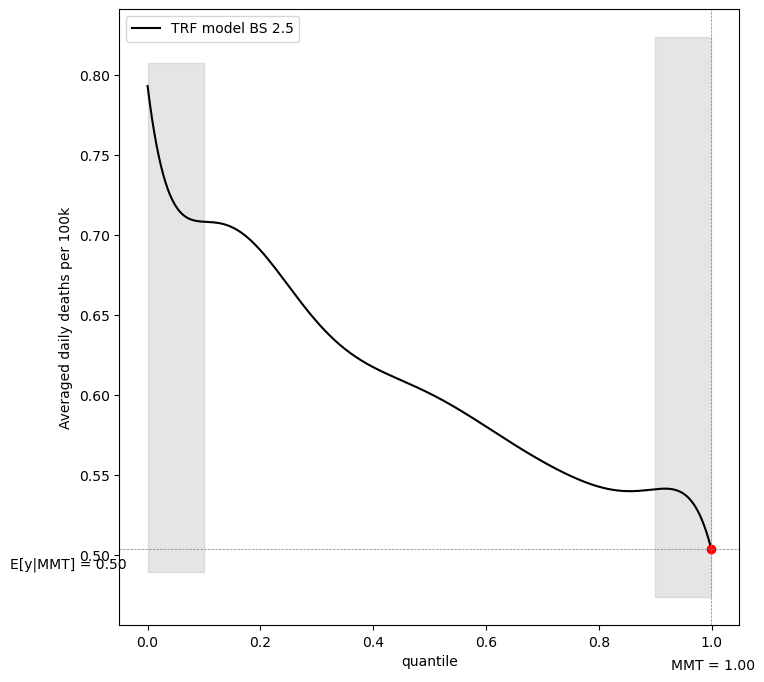

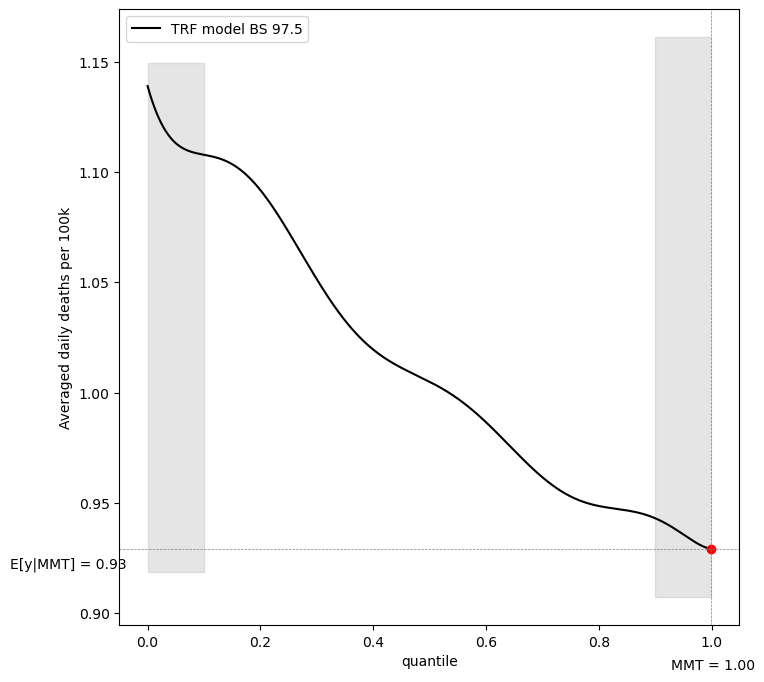

In [145]:
df_to_reg_bs = df_to_reg.merge(df_bootstrap[['y_star_2.5', 'y_star_97.5']],
                left_index=True, right_index=True)


pq_order = {'p':5, 'q':2}
dep_var  = 'y_star_2.5'
temp_r   = 'p_AirTemp'




model_trf_ln_low = ctrf.CTRF( df=df_to_reg_bs, 
                    dep= dep_var ,
                    temp_r= temp_r, 
                    pq_order=pq_order, 
                    cov_scale={'p_AirTemp':{'scale':'minmax'}})
model_trf_ln_low.estimate_ctrf(verbose=False)
# print(model_trf_ln_low.reg_res_ctrf.summary())


# model_trf_ln_low.reg_res_trf.summary()

model_trf_plot_bs_low = ctrf.plotting.Plot(df=df_to_reg_bs, ctrf_res=model_trf_ln_low)
model_trf_plot_bs_low.ctrf_plot(label='TRF model BS 2.5')
pq_order = {'p':5, 'q':2}
dep_var  = 'y_star_97.5'
temp_r   = 'p_AirTemp'




model_trf_ln_high = ctrf.CTRF( df=df_to_reg_bs, 
                    dep= dep_var ,
                    temp_r= temp_r, 
                    pq_order=pq_order, 
                    cov_scale={'p_AirTemp':{'scale':'minmax'}})
model_trf_ln_high.estimate_ctrf(verbose=False)
# print(model_trf_ln_high.reg_res_ctrf.summary())


# model_trf_ln_high.reg_res_trf.summary()
model_trf_plot_bs_high = ctrf.plotting.Plot(df=df_to_reg_bs, ctrf_res=model_trf_ln_high)
model_trf_plot_bs_high.ctrf_plot(label='TRF model BS 97.5')

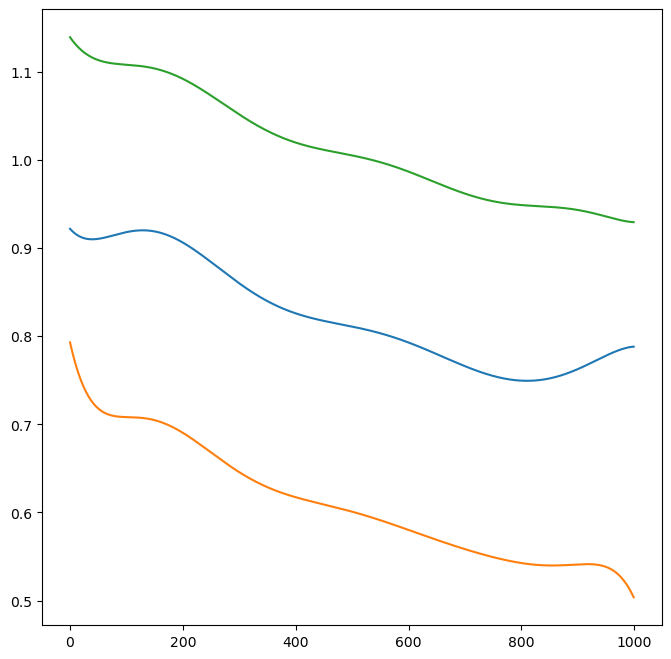

In [146]:
fig, ax = plt.subplots(figsize=(8,8))
# trf
ax.plot(model_trf_ln.recovered_trf)
# lb
ax.plot(model_trf_ln_low.recovered_trf)
# ub
ax.plot(model_trf_ln_high.recovered_trf)


plt.show()

## CTRF model

In [45]:
pq_order = {'p':5, 'q':2}
dep_var  = 'ln_daily_death100k'
temp_r   = 'p_AirTemp'

model_ctrf_ln = ctrf.CTRF( df=df_to_reg, 
                    dep= dep_var ,
                    temp_r= temp_r, 
                    pq_order= {'p':5, 'q':2}, 
                    cov_scale=covariates)
model_ctrf_ln.estimate_ctrf(verbose=False)
# model_ctrf_ln.reg_res_ctrf.summary()

In [46]:
# generate fitted residual df.
df_eta_ctrf = {}
df_eta_ctrf['base'] = pd.concat([df_to_reg[['fips','date']].copy(),
                    pd.DataFrame(model_ctrf_ln.Xs.dot(model_ctrf_ln.reg_res_ctrf.params[model_ctrf_ln.Xs.columns]),
                                  columns=['eta_hat']
                                  )
                                ],
                    axis=1)
df_eta_ctrf['base']

# mark max T
df_eta_ctrf['base'] = df_eta_ctrf['base'].merge(df_eta_ctrf['base'][['date']].drop_duplicates()
                                    .sort_values(by='date')
                                    .reset_index(drop=True)
                                    .reset_index()
                                    .rename(columns={'index':'T'}),
                                     on='date')
# df_eta_ctrf['base'] = df_eta_ctrf['base'].sort_values(by=['fips','date'], ascending=[True, False])
df_eta_ctrf['base']

,fips,date,eta_hat,T
0,01089,2002-12-01,0.907170,239
1,01089,2002-11-01,0.823706,238
2,01089,2002-10-01,0.784056,237
3,01089,2002-09-01,0.757438,236
4,01089,2002-08-01,0.761636,235
...,...,...,...,...
21355,55025,1983-05-01,0.783455,4
21356,55025,1983-04-01,0.765141,3
21357,55025,1983-03-01,0.808314,2
21358,55025,1983-02-01,0.874487,1


In [47]:
# reshape to wide while grouping fips to estimate rho_hat.
# add fips and t for safe.
# 24 lags...
df_fips_ctrf = {}

maxL, maxT = 24, df_eta_ctrf['base']['T'].max()

for _, L in enumerate(range(1,maxL+1)):
    if _ == 0 :
        colnames = [f'L{L}']
    else :
        colnames += [f'L{L}']


# for fips in df_eta_ctrf['base']['fips'].unique()[:] :
#     # T goes from 24 to 23,..0.
#     for T in range(0 + maxL, maxT + 1)[::-1] :
#         # 
#         _df = (df_eta_ctrf['base'].loc[
#                                     (df_eta_ctrf['base']['T'] == T) 
#                                     & 
#                                     (df_eta_ctrf['base']['fips'] == fips)
#                                     ])
#         # gen each row of lags.
#         # for L in range(1, maxL + 1) :
#         _df_eta_ctrf_L = (df_eta_ctrf['base'].loc[
#                                     (df_eta_ctrf['base']['T'].isin(range(T-maxL,T))) 
#                                     & 
#                                     (df_eta_ctrf['base']['fips'] == fips)
#                                     ]
#                                 )[['eta_hat']].set_index(np.array(colnames)).T#.rename(columns={'eta_hat':f'L{L}'})
#         _df_eta_ctrf_L.set_index(_df.index, inplace=True)
#         _df = pd.concat([ _df, _df_eta_ctrf_L ]
#                              ,axis=1)
#         # 
#         if T == maxT :
#             # initialize df - containing index and other meta
#             #   	    fips	date	eta_hat	T
#             #       719	01101	1983-01-01	-0.03769	0
#             df_fips_ctrf[f'{fips}'] = _df
#         else :
#             df_fips_ctrf[f'{fips}'] = pd.concat([df_fips_ctrf[f'{fips}'],
#                                             _df],
#                                             axis=0)


# df_eta_ctrf_regress = {}

# for _, fips in enumerate(df_eta_ctrf['base']['fips'].unique()[:]) :
#     if _ == 0 :
#         df_eta_ctrf_regress['base'] = df_fips_ctrf[f'{fips}']
#     else :
#         df_eta_ctrf_regress['base'] = pd.concat([df_eta_ctrf_regress['base'], df_fips_ctrf[f'{fips}']],
#                                    axis=0)

# df_eta_ctrf_regress['base']

In [48]:
def process_fips(fips, df_eta_ctrf, maxL, maxT):
    colnames = [f'L{L}' for L in range(1, maxL + 1)]
    df_fips_ctrf_fips = None

    for T in range(0 + maxL, maxT + 1)[::-1]:
        _df = df_eta_ctrf['base'].loc[
            (df_eta_ctrf['base']['T'] == T) & (df_eta_ctrf['base']['fips'] == fips)
        ]

        _df_eta_ctrf_L = (
            df_eta_ctrf['base'].loc[
                (df_eta_ctrf['base']['T'].isin(range(T - maxL, T))) & (df_eta_ctrf['base']['fips'] == fips)
            ][['eta_hat']]
            .set_index(np.array(colnames)).T
        )

        _df_eta_ctrf_L.set_index(_df.index, inplace=True)
        _df = pd.concat([_df, _df_eta_ctrf_L], axis=1)

        if T == maxT:
            df_fips_ctrf_fips = _df
        else:
            df_fips_ctrf_fips = pd.concat([df_fips_ctrf_fips, _df], axis=0)

    return fips, df_fips_ctrf_fips

# Parallel execution for fips loop
results = Parallel(n_jobs=-1)(
    delayed(process_fips)(fips, df_eta_ctrf, maxL, maxT)
    for fips in df_eta_ctrf['base']['fips'].unique()
)

# Collect results into the dictionary
df_fips_ctrf = {str(fips): df for fips, df in results}

def combine_fips_results(df_fips_ctrf, fips_list):
    df_combined = None
    for fips in fips_list:
        if df_combined is None:
            df_combined = df_fips_ctrf[f'{fips}']
        else:
            df_combined = pd.concat([df_combined, df_fips_ctrf[f'{fips}']], axis=0)
    return df_combined

# Combine results for regression
df_eta_ctrf_regress = {'base': combine_fips_results(df_fips_ctrf, df_eta_ctrf['base']['fips'].unique())}

# Output the final dataframe
df_eta_ctrf_regress['base']


,fips,date,eta_hat,T,L1,L2,L3,L4,L5,L6,...,L15,L16,L17,L18,L19,L20,L21,L22,L23,L24
0,01089,2002-12-01,0.907170,239,0.823706,0.784056,0.757438,0.761636,0.765005,0.759743,...,0.768598,0.758520,0.760031,0.758145,0.769358,0.783747,0.841886,0.833296,1.025327,1.109453
1,01089,2002-11-01,0.823706,238,0.784056,0.757438,0.761636,0.765005,0.759743,0.773201,...,0.758520,0.760031,0.758145,0.769358,0.783747,0.841886,0.833296,1.025327,1.109453,0.800067
2,01089,2002-10-01,0.784056,237,0.757438,0.761636,0.765005,0.759743,0.773201,0.783457,...,0.760031,0.758145,0.769358,0.783747,0.841886,0.833296,1.025327,1.109453,0.800067,0.784038
3,01089,2002-09-01,0.757438,236,0.761636,0.765005,0.759743,0.773201,0.783457,0.772609,...,0.758145,0.769358,0.783747,0.841886,0.833296,1.025327,1.109453,0.800067,0.784038,0.760709
4,01089,2002-08-01,0.761636,235,0.765005,0.759743,0.773201,0.783457,0.772609,0.884828,...,0.769358,0.783747,0.841886,0.833296,1.025327,1.109453,0.800067,0.784038,0.760709,0.764855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21331,55025,1985-05-01,0.760443,28,0.783277,0.772433,0.948590,1.236073,0.876922,0.796315,...,0.829476,1.102713,1.202354,0.771547,0.782567,0.763784,0.769004,0.793393,0.757779,0.783455
21332,55025,1985-04-01,0.783277,27,0.772433,0.948590,1.236073,0.876922,0.796315,0.783834,...,1.102713,1.202354,0.771547,0.782567,0.763784,0.769004,0.793393,0.757779,0.783455,0.765141
21333,55025,1985-03-01,0.772433,26,0.948590,1.236073,0.876922,0.796315,0.783834,0.763918,...,1.202354,0.771547,0.782567,0.763784,0.769004,0.793393,0.757779,0.783455,0.765141,0.808314
21334,55025,1985-02-01,0.948590,25,1.236073,0.876922,0.796315,0.783834,0.763918,0.769065,...,0.771547,0.782567,0.763784,0.769004,0.793393,0.757779,0.783455,0.765141,0.808314,0.874487


In [7]:
spec = f'eta_hat ~ L1'
for _ in range(2,maxL+1) :
    # print(_, elm)
    if _ > 1 :
        spec = spec + f' + L{_}'
spec = spec + '-1'

spec



yy,xx = dmatrices(spec, df_eta_ctrf_regress['base'], return_type='dataframe')

resid_res_ctrf = OLS(yy,xx).fit()
resid_res_ctrf.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                eta_hat   R-squared (uncentered):                   0.995
Model:                            OLS   Adj. R-squared (uncentered):              0.995
Method:                 Least Squares   F-statistic:                          1.703e+05
Date:                Sat, 04 Jan 2025   Prob (F-statistic):                        0.00
Time:                        11:45:00   Log-Likelihood:                          28283.
No. Observations:               19224   AIC:                                 -5.652e+04
Df Residuals:                   19200   BIC:                                 -5.633e+04
Df Model:                          24                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
L1             0.1680      0.007     24.031      0.000       0.154       0.182
L2             0.0044      0.007      0.634      0.526      -0.009       0.018
L3            -0.0007      0.007     -0.098      0.922      -0.014       0.013
L4             0.0046      0.007      0.653      0.514      -0.009       0.018
L5             0.0100      0.007      1.436      0.151      -0.004       0.024
L6            -0.0120      0.007     -1.722      0.085      -0.026       0.002
L7             0.0006      0.007      0.082      0.935      -0.013       0.014
L8            -0.0003      0.007     -0.040      0.968      -0.014       0.013
L9            -0.0302      0.007     -4.322      0.000      -0.044      -0.017
L10            0.0494      0.007      7.090      0.000       0.036       0.063
L11            0.0977      0.007     14.069      0.000       0.084       0.111
L12            0.2403      0.007     35.639      0.000       0.227       0.253
L13            0.1663      0.007     25.119      0.000       0.153       0.179
L14           -0.0699      0.007    -10.445      0.000      -0.083      -0.057
L15           -0.0094      0.007     -1.396      0.163      -0.023       0.004
L16            0.0132      0.007      1.966      0.049    3.69e-05       0.026
L17            0.0079      0.007      1.182      0.237      -0.005       0.021
L18           -0.0062      0.007     -0.933      0.351      -0.019       0.007
L19            0.0273      0.007      4.071      0.000       0.014       0.040
L20            0.0024      0.007      0.364      0.716      -0.011       0.016
L21           -0.0089      0.007     -1.334      0.182      -0.022       0.004
L22           -0.0233      0.007     -3.480      0.001      -0.036      -0.010
L23            0.1646      0.007     24.519      0.000       0.151       0.178
L24            0.2033      0.007     30.084      0.000       0.190       0.216
==============================================================================
Omnibus:                    17436.003   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1238980.466
Skew:                           4.120   Prob(JB):                         0.00
Kurtosis:                      41.456   Cond. No.                         85.7
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [52]:
df_e_demeaned_ctrf = pd.DataFrame(resid_res_ctrf.resid, columns=['e_hat'])
df_e_demeaned_ctrf = df_e_demeaned_ctrf.reset_index()
df_e_demeaned_ctrf = df_e_demeaned_ctrf.merge(df_eta_ctrf['base'][['date','fips']], how='left', left_on='index', right_index=True)
# demeaned with sample mean of e_hat.
# df_e_demeaned_ctrf['e_hat'] = df_e_demeaned_ctrf['e_hat'] - df_e_demeaned_ctrf['e_hat'].mean()
# # demeaned with sample mean of e_hat within fips.
# df_e_demeaned_ctrf = df_e_demeaned_ctrf.merge(df_e_demeaned_ctrf.groupby('fips')[['e_hat']].mean().reset_index().rename(columns={'e_hat':'e_hat_mean'}),
#                          on='fips', how='left')
# df_e_demeaned_ctrf['e_hat'] = df_e_demeaned_ctrf['e_hat'] - df_e_demeaned_ctrf['e_hat_mean']
df_e_demeaned_ctrf
df_e_demeaned_ctrf

,index,e_hat,date,fips
0,0,-0.009398,2002-12-01,01089
1,1,-0.009729,2002-11-01,01089
2,2,0.017321,2002-10-01,01089
3,3,-0.005469,2002-09-01,01089
4,4,-0.006824,2002-08-01,01089
...,...,...,...,...
19219,21331,-0.016223,1985-05-01,55025
19220,21332,-0.005612,1985-04-01,55025
19221,21333,-0.044442,1985-03-01,55025
19222,21334,0.023019,1985-02-01,55025


In [9]:
# df_e_demeaned_ctrf = pd.DataFrame(resid_res_ctrf.resid, columns=['e_hat'])
# # # demeaned with sample mean of e_hat.
# # df_e_demeaned_ctrf['e_hat'] = df_e_demeaned_ctrf['e_hat'] - df_e_demeaned_ctrf['e_hat'].mean()
# df_e_demeaned_ctrf = df_e_demeaned_ctrf.reset_index()
# df_e_demeaned_ctrf = df_e_demeaned_ctrf.merge(df_eta_ctrf['base'][['date','fips']], how='left', left_on='index', right_index=True)
# df_e_demeaned_ctrf

# bootstrapping "e_star" within cross sections from the demeaned "e_hat".
for b in range(1,1000)[:]:
    for _, fips in enumerate(df_e_demeaned_ctrf['fips'].unique()[:]) :
        rng = np.random.default_rng(seed=None)
        idx_cross_section = df_e_demeaned_ctrf[df_e_demeaned_ctrf['fips']==fips].index
        random_idx = rng.choice(idx_cross_section,
                                size=len(idx_cross_section))

        # generate bootstrapped "eta_star = fitted residual;e + fitted eta"
        if _ == 0 :
            # print(_df)
            _df = pd.DataFrame()
            # print(_df)
            _df = df_e_demeaned_ctrf[['e_hat']]
            _df[f'e_star_{b}'] = np.nan
            _df.loc[idx_cross_section, f'e_star_{b}'] = (_df.loc[idx_cross_section,'e_hat'] 
                                    + df_e_demeaned_ctrf.loc[random_idx,:'e_hat'].set_index(idx_cross_section)['e_hat'])
        # 
        else :
            _df.loc[idx_cross_section, f'e_star_{b}'] =(_df.loc[idx_cross_section,'e_hat']  
                                    + df_e_demeaned_ctrf.loc[random_idx,:'e_hat'].set_index(idx_cross_section)['e_hat'])

        
        # _df = pd.DataFrame(df_e_demeaned_ctrf.iloc[random_idx][['e_hat']].reset_index()['e_hat'] + df_e_demeaned_ctrf['e_hat'],
        #                     columns=[f'e_star_{_}'])
    df_e_demeaned_ctrf = pd.concat([df_e_demeaned_ctrf, _df[[f'e_star_{b}']]], axis=1)

df_e_demeaned_ctrf

,index,e_hat,date,fips,e_hat_mean,e_star_1,e_star_2,e_star_3,e_star_4,e_star_5,...,e_star_990,e_star_991,e_star_992,e_star_993,e_star_994,e_star_995,e_star_996,e_star_997,e_star_998,e_star_999
0,0,-0.009577,2002-12-01,01089,0.000179,-0.005659,-0.004840,-0.019485,0.002531,-0.004222,...,0.041951,-0.008825,-0.010673,-0.065543,-0.006505,0.042554,-0.037205,-0.019260,-0.014399,-0.011158
1,1,-0.009908,2002-11-01,01089,0.000179,0.120580,-0.009761,-0.009474,-0.065874,-0.018843,...,-0.062021,-0.002616,-0.060669,-0.010269,-0.016148,-0.007496,-0.115837,0.015257,-0.006388,-0.008857
2,2,0.017143,2002-10-01,01089,0.000179,-0.054033,0.053838,0.034994,0.013470,-0.036322,...,0.021609,0.016060,0.083572,-0.015834,0.003121,-0.033619,0.010903,0.019514,-0.013396,0.011736
3,3,-0.005648,2002-09-01,01089,0.000179,0.003315,-0.015981,-0.001731,-0.010118,0.011606,...,-0.030476,-0.003809,-0.001864,-0.018469,-0.011888,0.045682,0.011606,0.004921,-0.013279,-0.006153
4,4,-0.007003,2002-08-01,01089,0.000179,-0.007037,0.020997,0.047831,0.000289,-0.004922,...,-0.082532,-0.003933,0.009056,-0.002536,-0.005270,-0.011335,-0.007687,-0.082532,-0.001981,-0.016911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19219,21331,-0.015490,1985-05-01,55025,-0.000733,-0.019066,-0.007829,-0.025125,-0.052716,-0.141779,...,-0.043306,-0.090585,-0.030979,-0.020447,-0.021546,-0.027353,-0.024740,-0.079012,-0.023121,-0.077068
19220,21332,-0.004879,1985-04-01,55025,-0.000733,-0.008331,0.004039,0.124043,-0.042841,-0.016077,...,-0.068402,-0.053623,-0.010691,0.002782,-0.001527,-0.045595,-0.032696,-0.005428,0.014895,-0.008381
19221,21333,-0.043709,1985-03-01,55025,-0.000733,0.063584,-0.051340,-0.025346,-0.052507,-0.048225,...,-0.042090,-0.034941,-0.034812,-0.030711,-0.179130,-0.059581,-0.048726,-0.039974,0.028179,-0.111990
19222,21334,0.023752,1985-02-01,55025,-0.000733,0.018701,0.005717,-0.037826,-0.026053,0.012566,...,0.052201,-0.042637,0.017941,0.045202,-0.049162,0.040632,0.036339,0.015985,0.005335,0.009819


In [10]:
def process_b(b, df_eta_regress, df_e_demeaned, resid_res, model_trf_ln, maxL, maxT):
    df_eta_star_b = df_eta_regress.copy().drop(columns=['eta_hat'])
    # Fill NaN except the initial point
    df_eta_star_b.loc[df_eta_regress['T'] != 24, df_eta_regress.filter(like="L").columns] = np.nan
    df_eta_star_b['eta'] = np.nan
    df_eta_star_b['e_star'] = np.nan
    df_eta_star_b['eta_star'] = np.nan

    for _, T in enumerate(range(maxL, maxT + 1)):
        # Copy lagged data from previous T
        if T > maxL:
            # L1
            df_eta_star_b.loc[df_eta_star_b['T'] == T, 
                              df_eta_star_b.filter(like='L').columns[0]
                              ] = df_eta_star_b.loc[df_eta_star_b['T'] == T - 1, # make 1 lag.
                                                    'eta_star'].values
            # L2 to L24
            df_eta_star_b.loc[df_eta_star_b['T'] == T, 
                              df_eta_star_b.filter(like='L').columns[1:]] = df_eta_star_b.loc[df_eta_star_b['T'] == T - 1, 
                                                                                              df_eta_star_b.filter(like='L').columns[:-1]].values

        # Generate eta_star = eta + e_star
        eta = df_eta_star_b.loc[df_eta_star_b['T'] == T].filter(like='L').dot(resid_res.params)
        e_star = df_e_demeaned.loc[df_e_demeaned['index'].isin(df_eta_star_b.loc[df_eta_star_b['T'] == T].index)][f'e_star_{b}'].values
        eta_star = eta + e_star

        df_eta_star_b.loc[df_eta_star_b['T'] == T, ['eta']] = np.array(eta)
        df_eta_star_b.loc[df_eta_star_b['T'] == T, ['e_star']] = np.array(e_star)
        df_eta_star_b.loc[df_eta_star_b['T'] == T, ['eta_star']] = np.array(eta_star)

    # Fit y and merge
    df_eta_star_b = df_eta_star_b.merge(pd.DataFrame(model_trf_ln.reg_res_trf.predict(), columns=['fitted_y']), how='left', left_index=True, right_index=True)
    df_eta_star_b['y_star'] = df_eta_star_b['fitted_y'] + df_eta_star_b['eta_star']

    return b, df_eta_star_b

# Parallel execution of the loop
results = Parallel(n_jobs=-1)(
    delayed(process_b)(b, df_eta_ctrf_regress['base'], df_e_demeaned_ctrf, resid_res_ctrf, model_ctrf_ln, maxL, maxT) for b in range(1, 1000)[:]
)

# Collect results into the dictionary
df_eta_star_ctrf = {str(b): df for b, df in results}

In [100]:
df_eta_star_ctrf['1']

,fips,date,T,L1,L2,L3,L4,L5,L6,L7,...,L20,L21,L22,L23,L24,eta,e_star,eta_star,fitted_y,y_star
0,01089,2002-12-01,239,0.895300,0.636775,0.674066,0.674554,0.695535,0.743354,0.807230,...,0.837903,0.844209,0.844607,1.063860,1.137895,0.930610,-0.005659,0.924950,0.917785,1.842736
1,01089,2002-11-01,238,0.636775,0.674066,0.674554,0.695535,0.743354,0.807230,0.822452,...,0.844209,0.844607,1.063860,1.137895,0.758110,0.774720,0.120580,0.895300,0.879105,1.774405
2,01089,2002-10-01,237,0.674066,0.674554,0.695535,0.743354,0.807230,0.822452,0.786220,...,0.844607,1.063860,1.137895,0.758110,0.704280,0.690809,-0.054033,0.636775,0.798932,1.435707
3,01089,2002-09-01,236,0.674554,0.695535,0.743354,0.807230,0.822452,0.786220,0.891810,...,1.063860,1.137895,0.758110,0.704280,0.669276,0.670750,0.003315,0.674066,0.749842,1.423908
4,01089,2002-08-01,235,0.695535,0.743354,0.807230,0.822452,0.786220,0.891810,0.892479,...,1.137895,0.758110,0.704280,0.669276,0.677422,0.681591,-0.007037,0.674554,0.758211,1.432765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21331,55025,1985-05-01,28,0.798554,0.879643,0.943804,1.233296,0.876922,0.796315,0.783834,...,0.763784,0.769004,0.793393,0.757779,0.783455,0.779699,-0.019066,0.760633,0.754119,1.514752
21332,55025,1985-04-01,27,0.879643,0.943804,1.233296,0.876922,0.796315,0.783834,0.763918,...,0.769004,0.793393,0.757779,0.783455,0.765141,0.806885,-0.008331,0.798554,0.794100,1.592653
21333,55025,1985-03-01,26,0.943804,1.233296,0.876922,0.796315,0.783834,0.763918,0.769065,...,0.793393,0.757779,0.783455,0.765141,0.808314,0.816058,0.063584,0.879643,0.838245,1.717888
21334,55025,1985-02-01,25,1.233296,0.876922,0.796315,0.783834,0.763918,0.769065,0.764474,...,0.757779,0.783455,0.765141,0.808314,0.874487,0.925104,0.018701,0.943804,0.919984,1.863788


In [11]:
# construct y_star

df_y_star_ctrf = df_to_reg[['ln_daily_death100k']].rename(columns={'ln_daily_death100k':'y_star_0'}).copy()

for b in range(1,1000)[:]:
    df_y_star_ctrf = df_y_star_ctrf.merge(df_eta_star_ctrf[f'{b}'][['y_star']].rename(columns={'y_star':f'y_star_{b}'}),
                                how='right',
                                left_index=True,
                                right_index=True,
                                )

df_y_star_ctrf = df_y_star_ctrf.reset_index()
df_y_star_ctrf

,index,y_star_0,y_star_1,y_star_2,y_star_3,y_star_4,y_star_5,y_star_6,y_star_7,y_star_8,...,y_star_990,y_star_991,y_star_992,y_star_993,y_star_994,y_star_995,y_star_996,y_star_997,y_star_998,y_star_999
0,0,0.855992,1.842736,1.895691,1.787425,1.883006,1.806467,1.927219,1.826335,1.762540,...,1.950806,1.812612,1.803425,1.683383,1.736528,1.889175,1.765503,1.969567,1.815878,1.953802
1,1,0.772194,1.774405,1.791868,1.707061,1.682034,1.687023,1.764425,1.657382,1.628885,...,1.673839,1.641928,1.684865,1.587537,1.606613,1.677957,1.565716,1.946645,1.677149,1.802708
2,2,0.791772,1.435707,1.674450,1.656797,1.595948,1.569299,1.627305,1.502781,1.508138,...,1.521068,1.503317,1.705562,1.478916,1.492642,1.500154,1.477616,1.761285,1.538893,1.614255
3,3,0.664441,1.423908,1.529607,1.580710,1.494860,1.580077,1.550873,1.418068,1.458089,...,1.442679,1.454084,1.555496,1.454320,1.461373,1.540986,1.369432,1.609965,1.528981,1.525793
4,4,0.625645,1.432765,1.561118,1.616881,1.494469,1.583668,1.533895,1.506220,1.417172,...,1.431342,1.516661,1.554756,1.453877,1.498551,1.507690,1.384869,1.554155,1.589843,1.527934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19219,21331,0.523389,1.514752,1.524310,1.527800,1.471267,1.387024,1.510883,1.429599,1.524442,...,1.477108,1.432530,1.499180,1.513780,1.505634,1.496405,1.501215,1.451886,1.513397,1.450947
19220,21332,0.411348,1.592653,1.585357,1.708320,1.537179,1.565893,1.572166,1.522756,1.734861,...,1.515878,1.529271,1.573691,1.590269,1.556983,1.535514,1.549794,1.578056,1.609522,1.562801
19221,21333,0.730677,1.717888,1.601188,1.619946,1.594309,1.604895,1.592050,1.604044,1.638029,...,1.617592,1.611817,1.619106,1.636768,1.466877,1.599027,1.607375,1.613817,1.680405,1.540766
19222,21334,0.573287,1.863788,1.852894,1.809767,1.819206,1.856871,1.794961,1.846065,1.872610,...,1.895996,1.816653,1.861706,1.935153,1.811908,1.888906,1.875427,1.860787,1.851285,1.854622


In [63]:

df_bootstrap_ctrf = df_y_star_ctrf.reset_index()[['index']].copy()

# Define a function to perform the QuantileTransformer operation for each row
def process_row(idx, row, df_y_star_ctrf):
    q_trans = QuantileTransformer()
    q_trans.fit(pd.DataFrame(df_y_star_ctrf.filter(like='y_star_').loc[idx, :]))
    
    y_star_2_5 = q_trans.inverse_transform(np.array([[0.025]]))[0][0]
    y_star_97_5 = q_trans.inverse_transform(np.array([[0.975]]))[0][0]
    
    return idx, y_star_2_5, y_star_97_5

# Run the function in parallel
results = Parallel(n_jobs=-1)(delayed(process_row)(idx, row, df_y_star_ctrf) for idx, row in df_bootstrap_ctrf.iterrows())

# Update the df_bootstrap_ctrf with the parallel results
for idx, y_star_2_5, y_star_97_5 in results:
    df_bootstrap_ctrf.loc[idx, 'y_star_2.5'] = y_star_2_5
    df_bootstrap_ctrf.loc[idx, 'y_star_97.5'] = y_star_97_5

df_bootstrap_ctrf


,index,y_star_2.5,y_star_97.5
0,0,1.698274,1.959782
1,1,1.523710,1.791902
2,2,1.449110,1.723753
3,3,1.394574,1.672781
4,4,1.402420,1.659189
...,...,...,...
19219,21331,1.420556,1.750591
19220,21332,1.446723,1.789453
19221,21333,1.418758,1.778866
19222,21334,1.792354,2.053035


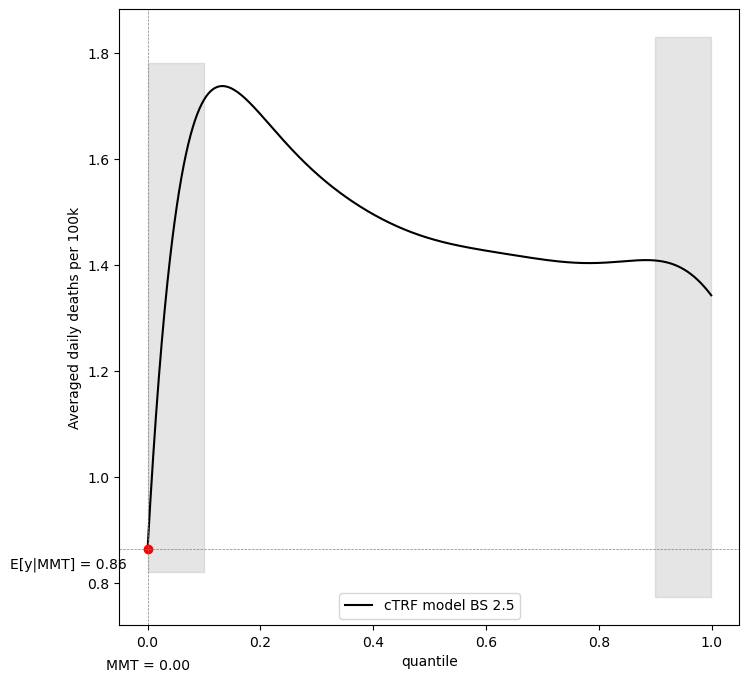

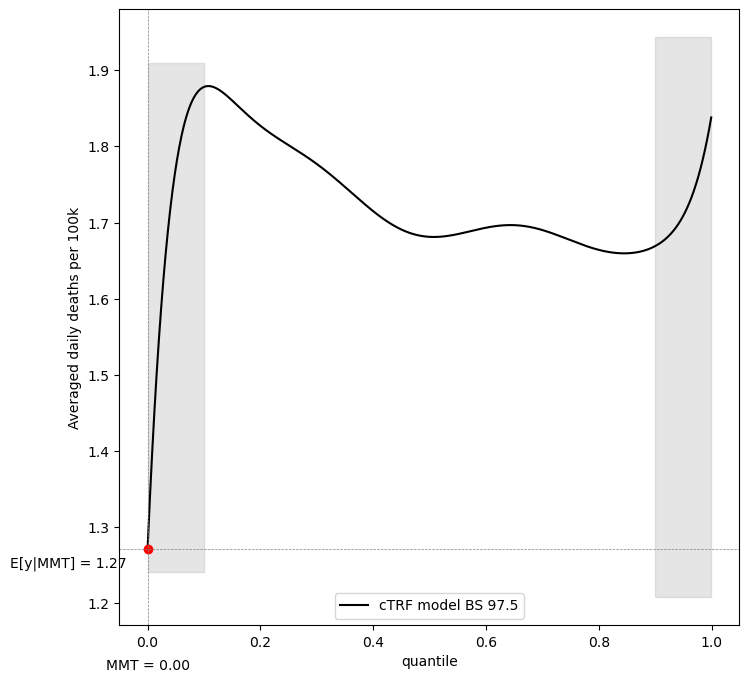

In [64]:
df_to_reg_bs_ctrf = df_to_reg.merge(df_bootstrap_ctrf[['y_star_2.5', 'y_star_97.5']],
                left_index=True, right_index=True)


pq_order = {'p':5, 'q':2}
dep_var  = 'y_star_2.5'
temp_r   = 'p_AirTemp'




model_ctrf_ln_low = ctrf.CTRF( df=df_to_reg_bs_ctrf, 
                    dep= dep_var ,
                    temp_r= temp_r, 
                    pq_order=pq_order, 
                    cov_scale=covariates
                    # cov_scale={'p_AirTemp':{'scale':'minmax'}}
                    )
model_ctrf_ln_low.estimate_ctrf(verbose=False)
# print(model_ctrf_ln_low.reg_res_ctrf.summary())


# model_ctrf_ln_low.reg_res_trf.summary()

model_trf_plot_bs_low = ctrf.plotting.Plot(df=df_to_reg_bs_ctrf, ctrf_res=model_ctrf_ln_low)
model_trf_plot_bs_low.ctrf_plot(label='cTRF model BS 2.5')

# pq_order = {'p':5, 'q':2}
dep_var  = 'y_star_97.5'
# temp_r   = 'p_AirTemp'




model_ctrf_ln_high = ctrf.CTRF( df=df_to_reg_bs_ctrf, 
                    dep= dep_var ,
                    temp_r= temp_r, 
                    pq_order=pq_order, 
                    cov_scale=covariates
                    # cov_scale={'p_AirTemp':{'scale':'minmax'}}
                    )
model_ctrf_ln_high.estimate_ctrf(verbose=False)
# print(model_ctrf_ln_high.reg_res_ctrf.summary())


# model_ctrf_ln_high.reg_res_trf.summary()
model_ctrf_plot_bs_high = ctrf.plotting.Plot(df=df_to_reg_bs_ctrf, ctrf_res=model_ctrf_ln_high)
model_ctrf_plot_bs_high.ctrf_plot(label='cTRF model BS 97.5')

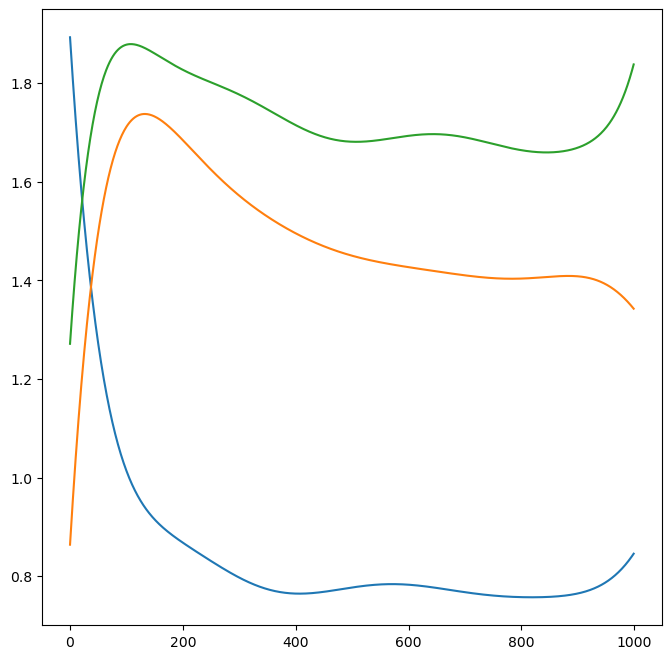

In [65]:
fig, ax = plt.subplots(figsize=(8,8))
# trf
ax.plot(model_ctrf_ln.recovered_ctrf['base'])
# lb
ax.plot(model_ctrf_ln_low.recovered_ctrf['base'])
# ub
ax.plot(model_ctrf_ln_high.recovered_ctrf['base'])


plt.show()

In [58]:
model_ctrf_ln.Xs.dot(model_ctrf_ln.reg_res_ctrf.params[model_ctrf_ln.Xs.columns])

0        0.907170
1        0.823706
2        0.784056
3        0.757438
4        0.761636
           ...   
21355    0.783455
21356    0.765141
21357    0.808314
21358    0.874487
21359    0.957829
Length: 21360, dtype: float64

In [24]:
df_tt = df_to_reg_bs_ctrf[['p_AirTemp','y_star_2.5','ln_daily_death100k','y_star_97.5']]
df_tt['temp'] = df_tt['p_AirTemp'].round(3)
df_tt.groupby('temp').mean().reset_index()

,temp,p_AirTemp,y_star_2.5,ln_daily_death100k,y_star_97.5
0,0.044,0.043527,0.726867,0.550148,1.147399
1,0.047,0.047235,0.732367,0.687349,1.159784
2,0.049,0.049267,0.688304,1.048288,1.110291
3,0.058,0.058368,0.806502,1.110894,1.174232
4,0.061,0.060848,0.803507,0.690284,1.163740
...,...,...,...,...,...
846,0.909,0.908968,0.601021,0.488507,1.064503
847,0.911,0.910784,0.633850,0.957942,0.916692
848,0.916,0.916340,0.155934,0.539411,0.837399
849,0.919,0.919278,0.430741,0.859330,0.870589
